In [45]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
import os
os.chdir('/Users/kadofong/work/projects/merian/pieridae/merger_analysis/notebooks')

In [274]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Add pieridae to path
sys.path.insert(0, str(Path.cwd().parents[1]))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import pickle
import logging
from typing import Dict, Tuple

from pieridae.starbursts.byol import (
    EmbeddingAnalyzer,
    LabelPropagation,
    compute_classification_metrics
)

# Import make_punchlines module
sys.path.insert(0, str(Path.cwd().parent / 'figure_generation'))
import make_punchlines

# Plotting utilities
from ekfplot import plot as ek, colors as ec, colorlists
from ekfphys import calibrations
from ekfstats import sampling

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
# Setup logger
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

In [394]:
agg_data = make_punchlines.load_data_multirun(Path('../output/'),
                                          ['fiducial'] + [f'fiducial_rerun_{ix}' for ix in range(5)],
                                          logger
)

/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kadofong/work/projects/merian/carpenter/src/carpenter/emission.py:338: RuntimeWarning: divide by zero encountered in reciprocal
  emission_correction = correct_NIISII(redshift_values, aperture_corrected_logmass)**-1


Computed aperture correction in 0.0 seconds.
Computed line contamination correction in 0.0 seconds.
Loading precomputed Galactic extinction map...
Interpolated Galactic extinction values from map.
Computed Galactic extinction correction in 0.7 seconds.
Computed internal extinction corrections in 0.8 seconds.


/Users/kadofong/work/projects/merian/agrias/python/agrias/photometry.py:115: RuntimeWarning: invalid value encountered in log10
  lsq_y = np.log10(np.array([ fdict[band] for band in plawbands ]))
/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kadofong/work/projects/merian/pieridae/merger_analysis/figure_generation/make_punchlines.py:331: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/Users/kadofong/.cache/merian/logmass_adjusted.csv


/Users/kadofong/work/projects/merian/pieridae/merger_analysis/figure_generation/make_punchlines.py:382: DtypeWarning: Columns (369,376,377,378,395,414,416,419,422,424,427,430) have mixed types. Specify dtype option on import or set low_memory=False.
  lucas = pd.read_csv(lucas_file)
/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kadofong/work/projects/merian/carpenter/src/carpenter/emission.py:338: RuntimeWarning: divide by zero encountered in reciprocal
  emission_correction = correct_NIISII(redshift_values, aperture_corrected_logmass)**-1


...

/Users/kadofong/work/projects/merian/pieridae/merger_analysis/figure_generation/make_punchlines.py:382: DtypeWarning: Columns (369,376,377,378,395,414,416,419,422,424,427,430) have mixed types. Specify dtype option on import or set low_memory=False.
  lucas = pd.read_csv(lucas_file)
/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kadofong/work/projects/merian/carpenter/src/carpenter/emission.py:338: RuntimeWarning: divide by zero encountered in reciprocal
  emission_correction = correct_NIISII(redshift_values, aperture_corrected_logmass)**-1


Computed aperture correction in 0.0 seconds.
Computed line contamination correction in 0.0 seconds.
Loading precomputed Galactic extinction map...
Interpolated Galactic extinction values from map.
Computed Galactic extinction correction in 0.7 seconds.
Computed internal extinction corrections in 0.7 seconds.


/Users/kadofong/work/projects/merian/agrias/python/agrias/photometry.py:115: RuntimeWarning: invalid value encountered in log10
  lsq_y = np.log10(np.array([ fdict[band] for band in plawbands ]))
/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kadofong/work/projects/merian/pieridae/merger_analysis/figure_generation/make_punchlines.py:331: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/Users/kadofong/.cache/merian/logmass_adjusted.csv


/Users/kadofong/work/projects/merian/pieridae/merger_analysis/figure_generation/make_punchlines.py:382: DtypeWarning: Columns (369,376,377,378,395,414,416,419,422,424,427,430) have mixed types. Specify dtype option on import or set low_memory=False.
  lucas = pd.read_csv(lucas_file)


In [377]:
runs = {
    'run0': {
        'path': Path('../output/fiducial/'),
        'label': 'ref',
        'color': 'C0',
        'description': 'Baseline BYOL model with standard hyperparameters'
    },
}
for ix in range(5):
    runs[f'run{ix+1}'] = {
        'path': Path(f'../output/fiducial_rerun_{ix}/'),
        'label': f'rerun{ix+1}',
        'color': f'C{ix+1}',
        'description': 'Modified BYOL model with different configuration'
    }

data = {}
for rid in range(len(runs.keys())):
    name = f'run{rid}'
    config_path =  runs[name]['path'] / 'effective_config.yaml'
    run_config = make_punchlines.load_config(config_path)
    
    data[name] = make_punchlines.load_data(
                    run_config,
                    logger,
                    update_masses=False,
                    use_nn_classifier=True
                )

catalog = data['run0']['catalog']
img_names = data['run0']['img_names'] 



has_label = s_prob_labels[:,1] < 0.05

/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kadofong/work/projects/merian/carpenter/src/carpenter/emission.py:338: RuntimeWarning: divide by zero encountered in reciprocal
  emission_correction = correct_NIISII(redshift_values, aperture_corrected_logmass)**-1


Computed aperture correction in 0.0 seconds.
Computed line contamination correction in 0.0 seconds.
Loading precomputed Galactic extinction map...
Interpolated Galactic extinction values from map.
Computed Galactic extinction correction in 0.7 seconds.
Computed internal extinction corrections in 0.8 seconds.


/Users/kadofong/work/projects/merian/agrias/python/agrias/photometry.py:115: RuntimeWarning: invalid value encountered in log10
  lsq_y = np.log10(np.array([ fdict[band] for band in plawbands ]))
/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kadofong/work/projects/merian/pieridae/merger_analysis/figure_generation/make_punchlines.py:331: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/Users/kadofong/.cache/merian/logmass_adjusted.csv


/Users/kadofong/work/projects/merian/pieridae/merger_analysis/figure_generation/make_punchlines.py:382: DtypeWarning: Columns (369,376,377,378,395,414,416,419,422,424,427,430) have mixed types. Specify dtype option on import or set low_memory=False.
  lucas = pd.read_csv(lucas_file)
/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kadofong/work/projects/merian/carpenter/src/carpenter/emission.py:338: RuntimeWarning: divide by zero encountered in reciprocal
  emission_correction = correct_NIISII(redshift_values, aperture_corrected_logmass)**-1


...

/Users/kadofong/work/projects/merian/pieridae/merger_analysis/figure_generation/make_punchlines.py:382: DtypeWarning: Columns (369,376,377,378,395,414,416,419,422,424,427,430) have mixed types. Specify dtype option on import or set low_memory=False.
  lucas = pd.read_csv(lucas_file)
/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kadofong/work/projects/merian/carpenter/src/carpenter/emission.py:338: RuntimeWarning: divide by zero encountered in reciprocal
  emission_correction = correct_NIISII(redshift_values, aperture_corrected_logmass)**-1


Computed aperture correction in 0.0 seconds.
Computed line contamination correction in 0.0 seconds.
Loading precomputed Galactic extinction map...
Interpolated Galactic extinction values from map.
Computed Galactic extinction correction in 0.7 seconds.
Computed internal extinction corrections in 0.8 seconds.


/Users/kadofong/work/projects/merian/agrias/python/agrias/photometry.py:115: RuntimeWarning: invalid value encountered in log10
  lsq_y = np.log10(np.array([ fdict[band] for band in plawbands ]))
/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kadofong/work/projects/merian/pieridae/merger_analysis/figure_generation/make_punchlines.py:331: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/Users/kadofong/.cache/merian/logmass_adjusted.csv


/Users/kadofong/work/projects/merian/pieridae/merger_analysis/figure_generation/make_punchlines.py:382: DtypeWarning: Columns (369,376,377,378,395,414,416,419,422,424,427,430) have mixed types. Specify dtype option on import or set low_memory=False.
  lucas = pd.read_csv(lucas_file)


In [378]:
nruns = len(data.keys())
prob_labels_arr = np.zeros([nruns, *data['run0']['prob_labels_iter'].shape])
for ix in range(nruns):
    prob_labels_arr[ix] = data[f'run{ix}']['prob_labels_iter']

In [379]:
m_prob_labels = prob_labels_arr.mean(axis=0)
s_prob_labels = prob_labels_arr.std(axis=0)

pmerger = m_prob_labels[:,2]+m_prob_labels[:,3]
u_pmerger = np.sqrt(s_prob_labels[:,2]**2 + s_prob_labels[:,3]**2)



In [382]:
merianid_uncertain = 'M3321932490767093822'
cid_uncertain = np.where(data['run0']['img_names']==merianid_uncertain)[0][0]
prob_labels_arr[:,cid_uncertain,[1]]

array([[0.41552028],
       [0.04988338],
       [0.98172343],
       [0.10379179],
       [0.06074514],
       [0.97610813]])

In [395]:
m_prob_labels[cid_certain]

array([0.        , 0.20928963, 0.45018903, 0.297634  , 0.03475473,
       0.0081326 ])

In [396]:
s_prob_labels[cid_certain]

array([0.        , 0.04133725, 0.04099334, 0.06869743, 0.0241168 ,
       0.01222393])

In [397]:
agg_data['mean_prob_labels'][cid_certain]

array([0.        , 0.20928963, 0.45018903, 0.297634  , 0.03475473,
       0.0081326 ])

In [381]:
merianid_certain = 'M3242838022311418435'
cid_certain = np.where(data['run0']['img_names']==merianid_certain)[0][0]
prob_labels_arr[:,cid_certain,[1,2,3]]

array([[0.19271427, 0.49618572, 0.28527758],
       [0.181182  , 0.50340927, 0.30140418],
       [0.17500144, 0.41355935, 0.32427976],
       [0.27340493, 0.47003123, 0.1704167 ],
       [0.17318007, 0.40994504, 0.40367731],
       [0.26025507, 0.4080036 , 0.3007485 ]])

In [331]:
# Compute SFS relation
alpha = -0.13 * 0.08 + 0.8
norm = 1.24 * 0.08 - 1.47
sfs_std = 0.22 * 0.08 + 0.38
sfs = lambda logmstar: alpha * (logmstar - 8.5) + norm

# Compute distance from SFS
dsfs = np.log10(calibrations.LHa2SFR(catalog.reindex(img_names)['L_Ha'])) - sfs(catalog.reindex(img_names)['logmass_adjusted'])
mask = abs(dsfs / sfs_std) < 0.2

In [339]:
inband_specz = (catalog.reindex(img_names)['z_spec']>0.04)&(catalog.reindex(img_names)['z_spec']<0.12)

In [354]:
(s_prob_labels[:,1]<1.).shape

(22360,)

/Users/kadofong/work/ekfutils/ekfstats/ekfstats/sampling.py:573: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ypull = y
/Users/kadofong/work/ekfutils/ekfstats/ekfstats/sampling.py:573: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ypull = y
/Users/kadofong/work/ekfutils/ekfstats/ekfstats/sampling.py:573: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ypull = y
/Users/kadofong/work/ekfutils/ekfstats/ekfstats/sampling.py:590: RuntimeW

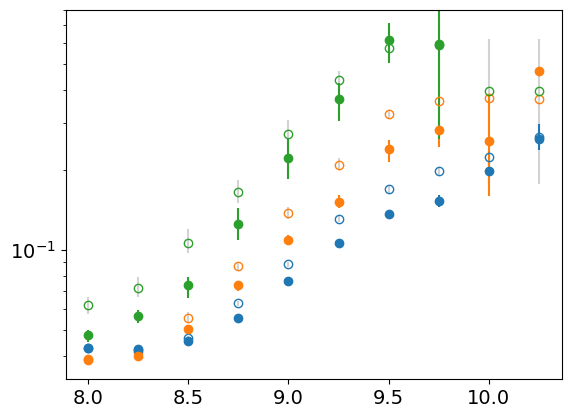

In [359]:
# [dsfs<100., inband_specz]
for idx,has_label in enumerate([s_prob_labels[:,1]<1., s_prob_labels[:,1]<0.05]):
    masks = [abs(dsfs / sfs_std) < 0.2, (dsfs/sfs_std>1.)&(dsfs/sfs_std<1.5), dsfs/sfs_std>2.]
    for jdx, mask in enumerate(masks):
        midpts, ystats, _ = sampling.running_metric(
            catalog.reindex(img_names).loc[has_label&mask, 'logmass_adjusted'],
            pmerger[has_label&mask],
            np.nanmean,
            np.linspace(8., 10.25, 10),
            yerr=u_pmerger[has_label&mask],
            erronmetric=True
        )  
        
        ek.errorbar(
            midpts,
            ystats[:,0,2],
            ylow=ystats[:,0,1],
            yhigh=ystats[:,0,3],
            markerfacecolor=idx==0 and 'None' or f'C{jdx}',
            markeredgecolor=f'C{jdx}',
            ecolor = idx==0 and 'lightgrey' or f'C{jdx}',
            #marker = idx==0 and 'o' or 'x'
        )
    plt.yscale('log')

In [213]:
possible_merger = ((prob_labels_arr[:,:,2] + prob_labels_arr[:,:,3])>0.3).any(axis=0)

In [214]:
prob_labels_arr[:,[cid_certain,cid_uncertain],2:4].shape

(4, 2, 2)

(array([ 8.70578202,  8.89975102,  9.09372003,  9.28768904,  9.48165805,
         9.67562706,  9.86959606, 10.06356507, 10.25753408]),
 array([[0.04485369, 0.0632028 , 0.08448256],
        [0.03808586, 0.05556798, 0.07865092],
        [0.03375593, 0.05075872, 0.07630165],
        [0.03371146, 0.05429141, 0.08348943],
        [0.03511658, 0.05948349, 0.09025226],
        [0.04173525, 0.06415461, 0.10379162],
        [0.04241309, 0.06895402, 0.10834291],
        [0.04554007, 0.07307132, 0.10981647],
        [0.04453631, 0.07077406, 0.10060545]]))

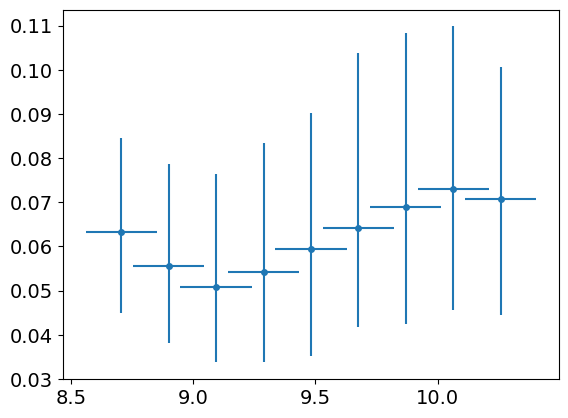

In [215]:
ek.running_quantile(
    catalog.reindex(img_names).loc[possible_merger,'logmass_adjusted'],
    np.std(prob_labels_arr[:,possible_merger,2:4].sum(axis=2), axis=0),
    bins=10
)